In [5]:
%reload_ext autoreload
%autoreload 2

In [2]:
from VirusHostNetworkAnalysis.prediction_matrix import PredictionMatrix
from VirusHostNetworkAnalysis.properties import BipartiteGraph
from VirusHostNetworkAnalysis.null_model import ConfigurationModel

In [7]:
nested_data = PredictionMatrix('tests/test_nestedness.tsv')
nested_data.make_rectangular_matrix()
nested_prop = BipartiteGraph(nested_data)
nested_prop.sort_matrix()
print(nested_prop.input_matrix)

[[False  True  True  True  True]
 [ True False  True  True False]
 [ True  True  True False False]
 [ True  True False False False]
 [ True  True False False False]]


In [8]:
nested_prop.run_nestedness()

58.33333333333333

In [47]:
subset_100_2000 = PredictionMatrix('Sample_Input/filtered_network.tsv')
subset_100_2000.make_rectangular_matrix()

array([[ True, False,  True, ..., False,  True, False],
       [ True,  True,  True, ...,  True, False,  True],
       [ True, False,  True, ..., False,  True, False],
       ...,
       [ True,  True, False, ..., False, False, False],
       [False,  True,  True, ..., False,  True, False],
       [ True,  True,  True, ...,  True, False,  True]])

In [48]:
subset_100_2000_prop = BipartiteGraph(subset_100_2000)

In [49]:
subset_100_2000_prop.run_parallel(8)

69.17555395852854

In [39]:
subset_100_2000_prop.run_nestedness()

69.17555395852854

In [41]:
subset_7_10000 = PredictionMatrix('Sample_Input/subset_7x10000.tsv')
subset_7_10000.make_rectangular_matrix()

array([[ True, False, False, ..., False, False, False],
       [ True,  True, False, ...,  True,  True,  True],
       [ True,  True,  True, ..., False,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False],
       [ True,  True,  True, ...,  True,  True,  True]])

In [42]:
subset_7_10000_prop = BipartiteGraph(subset_7_10000)
subset_7_10000_prop.run_parallel(8)

72.78848726401175

In [3]:
myco_large = PredictionMatrix('Sample_Input/myco_predictions_genomad_a2vs_updated.tsv')
myco_large.make_rectangular_matrix()

array([[ True, False, False, ..., False, False, False],
       [ True,  True, False, ...,  True,  True,  True],
       [ True,  True,  True, ..., False,  True,  True],
       ...,
       [ True, False,  True, ...,  True,  True,  True],
       [ True, False,  True, ...,  True,  True,  True],
       [ True,  True,  True, ..., False,  True,  True]])

In [5]:
from matplotlib.pylab import eig
import numpy as np
test_matrix = PredictionMatrix('tests/test_predictions.tsv', False)
test_matrix.make_rectangular_matrix()
test_properties = BipartiteGraph(test_matrix)

# Test #1
test_properties.input_matrix = np.array([[1, 1],
                                        [1, 0],
                                        [0, 1],
                                        [0, 1]])
test_properties.rows = np.array(["v2", "v3", "v5", "v6"])
test_properties.columns = np.array(["h1", "h4"])
test_properties.initialize_graph()
test_properties.calculate_centrality("eigenvector")
print(test_properties.eigenvector_virus)
print(test_properties.eigenvector_host)


{'v2': 0.5116687042046243, 'v3': 0.19544325298260648, 'v5': 0.3162254512220179, 'v6': 0.3162254512220179}
{'h1': 0.37175243743550507, 'h4': 0.6014982337968756}


In [35]:
# test shuffle
test = PredictionMatrix('tests/test_predictions.tsv', False)
test.make_rectangular_matrix()
test.virus_host_array = np.array([[1, 1, 1, 1, 1],
                                  [1, 1, 0, 1, 1],
                                  [1, 0, 1, 1, 0],
                                  [1, 1, 0, 0, 0],
                                  [1, 0, 1, 0, 0],
                                  [0, 1, 0, 0, 0],
                                  [1, 0, 0, 0, 0],
                                  [0, 0, 0, 0, 0]])
test_properties = BipartiteGraph(test)
print(test_properties.calculate_degree())
test_cm = ConfigurationModel(test)
test_cm.method2(0.6, 0.6)
print(test_cm.virus_host_array)
test_cm_properties = BipartiteGraph(test_cm)
print(test_cm_properties.calculate_degree())


[[5, 4, 3, 2, 2, 1, 1, 0], [6, 4, 3, 3, 2]]
[[0 0 1 0 0]
 [0 0 1 1 1]
 [1 1 1 0 1]
 [0 1 1 0 0]
 [0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 1 0]
 [1 1 1 1 1]]
[[1, 3, 4, 2, 0, 1, 2, 5], [2, 4, 6, 3, 3]]


In [4]:
# test time
aug4 = PredictionMatrix('Sample_Input/aug4_predictions.tsv', False)
aug4.make_rectangular_matrix()
aug4_cm = ConfigurationModel(aug4)
aug4_cm.bootstrap_stats(1000000)

In [5]:
aug4_cm_properties = BipartiteGraph(aug4_cm)
aug4_cm_properties.run_parallel(8)

['49640--k141_111749||full.fasta' '49618--k141_678278||full.fasta'
 '49623--k141_121963||full.fasta' ... '49620--k141_186575||full.fasta'
 '49623--k141_179749||full.fasta' '49617--k141_3641||full.fasta'] 6408
[1531  141 2543 ... 3455 3464 3203] 6408


63.13871075732342

In [28]:
aug4_cm_properties.calculate_centrality("betweenness", 2000)

Number of processes: 32
[('49623--k141_46368||full.fasta', '49623--k141_264109_1.fasta', '49620--k141_47043_1.fasta', '49640--k141_12662||full.fasta', '49618--k141_457467||full.fasta', '49616--k141_395429_1.fasta', '49618--k141_116154_1.fasta', '49640--k141_172294||full.fasta', '49640--k141_242961||full.fasta', '49620--k141_102789||full.fasta', '49614--k141_294537_1.fasta', '49623--k141_183280_1.fasta', '49640--k141_193135||full.fasta', '49640--k141_85779||full.fasta', '49620--k141_164239||full.fasta', '49617--k141_91948||full.fasta', '49617--k141_808_1.fasta', '49640--k141_45082||full.fasta', '49640--k141_126747||full.fasta', '49617--k141_128358_1.fasta', '49614--k141_157291||full.fasta', '49617--k141_118517||full.fasta', '49620--k141_188227_1.fasta', '49640--k141_113279||full.fasta', 'concatenated_49623_vRhyme_bin_271.fasta', '49618--k141_524574_1.fasta', '49640--k141_227465||full.fasta', '49621--k141_104702||full.fasta', '49623--k141_64917_1.fasta', '49640--k141_38210||full.fasta', 

In [9]:
btwn_virus_parallel = aug4_cm_properties.betweenness_virus
btwn_host_parallel = aug4_cm_properties.betweenness_host

In [10]:
aug4_cm_properties.calculate_centrality("betweenness", 2000)

In [11]:
btwn_virus = aug4_cm_properties.betweenness_virus
btwn_host = aug4_cm_properties.betweenness_host

In [18]:
from math import isclose
import numpy as np
# check if the parallel and non-parallel results are the same
# results are dictionaries with virus/host names as keys and betweenness values as values
for key in btwn_virus_parallel.keys():
    assert np.isclose(btwn_virus_parallel[key], btwn_virus[key], rtol=1e-5, atol=1e-8)
    if np.isclose(btwn_virus_parallel[key], btwn_virus[key], rtol=1e-5, atol=1e-8) is False:
        print(f"Virus {key} is not close")
for key in btwn_host_parallel.keys():
    assert np.isclose(btwn_host_parallel[key], btwn_host[key], rtol=1e-5, atol=1e-8)
    if np.isclose(btwn_host_parallel[key], btwn_host[key], rtol=1e-5, atol=1e-8) is False:
        print(f"Host {key} is not close")

In [19]:
from multiprocessing import cpu_count
cpu_count()

8

In [31]:
""" Test the calculate_eigenvector_centrality() function of the BipartiteGraph class."""
test_matrix = PredictionMatrix('tests/test_predictions.tsv', False)
test_matrix.make_rectangular_matrix()
test_matrix.rows = np.array(["v2", "v3", "v5", "v6"])
test_matrix.columns = np.array(["h1", "h4"])
test_properties = BipartiteGraph(test_matrix)

# Test #1
test_properties.input_matrix = np.array([[1, 1],
                                [1, 0],
                                [0, 1],
                                [0, 1]])
test_properties.rows = np.array(["v2", "v3", "v5", "v6"])
test_properties.columns = np.array(["h1", "h4"])
test_properties.initialize_graph()

test_properties.calculate_centrality("betweenness", 2000)

Number of processes: 32
[('v2',), ('v3',), ('v5',), ('v6',), ('h1',), ('h4',)]
Number of chunks: 6
Graph with 6 nodes and 5 edges


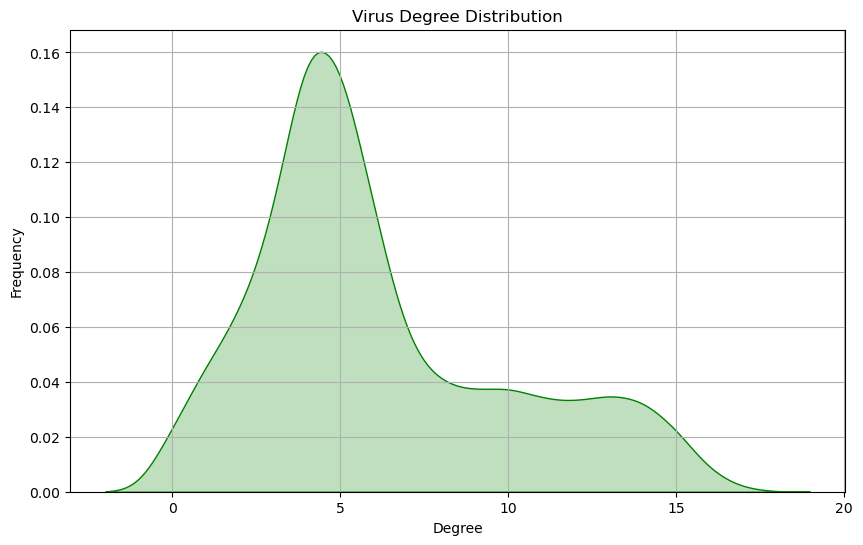

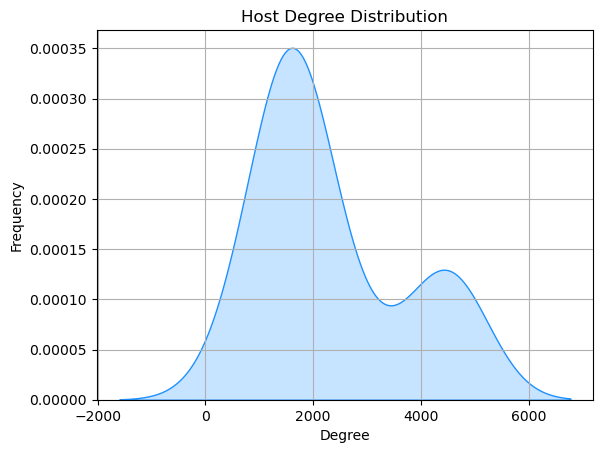

<Figure size 1000x600 with 0 Axes>

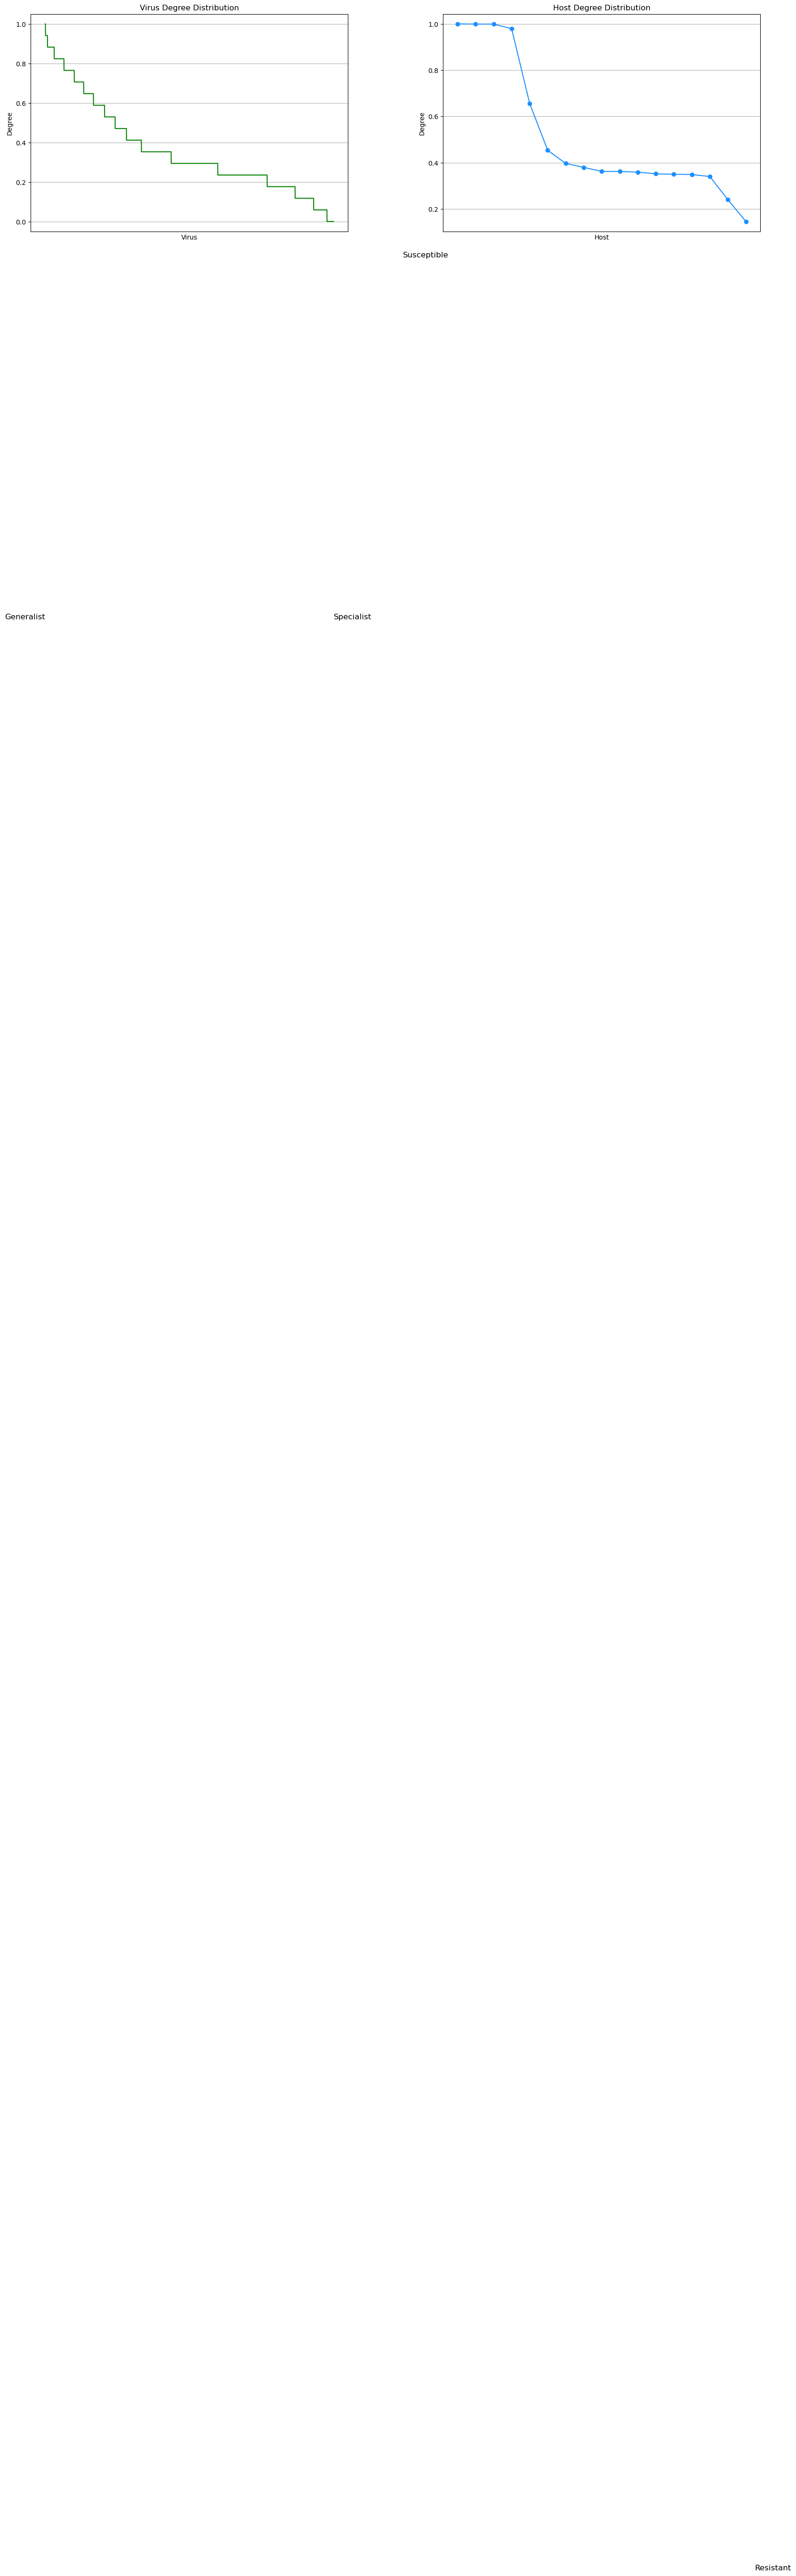

In [9]:
# Test the Aug 4 dataset
aug4 = PredictionMatrix('Sample_Input/aug4_predictions.tsv')
aug4.make_rectangular_matrix()
aug4_prop = BipartiteGraph(aug4)
aug4_prop.plot_degree_distribution()
aug4_prop.plot_degree_by_species()